In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import shutil
import numpy as np
import zipfile
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNet, VGG19
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess

from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping


In [ ]:
zip_path = '/content/drive/MyDrive/Pediatric Chest X-ray Pneumonia.zip'
extract_path = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray'

In [ ]:
# Check if folder already exists to avoid overwriting
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

In [ ]:
# List folders
for root, dirs, files in os.walk(extract_path):
    print(root, dirs[:5])

/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray ['test', 'train', 'chest_xray_split']
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/test ['NORMAL', 'PNEUMONIA']
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/test/NORMAL []
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/test/PNEUMONIA []
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/train ['NORMAL', 'PNEUMONIA']
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/train/NORMAL []
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/train/PNEUMONIA []
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split ['train', 'val', 'test', 'train_augmented']
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/train ['NORMAL', 'PNEUMONIA']
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/train/NORMAL []
/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_s

In [ ]:
train_dir = os.path.join(extract_path, "train")
test_dir = os.path.join(extract_path, "test")

def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))
    return normal, pneumonia

train_normal, train_pneumonia = count_images(train_dir)
test_normal, test_pneumonia = count_images(test_dir)

print(f"Train set → Normal: {train_normal}, Pneumonia: {train_pneumonia}")
print(f"Test set  → Normal: {test_normal}, Pneumonia: {test_pneumonia}")

Train set → Normal: 1349, Pneumonia: 3883
Test set  → Normal: 234, Pneumonia: 390


Split the Data

In [ ]:
# Base directory for split dataset
base_dir = "/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split"
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

In [ ]:
# Create subdirectories
for split in ['train', 'val', 'test']:
    for category in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(base_dir, split, category), exist_ok=True)

# --- Split Train into Train + Validation ---
normal_images = os.listdir(os.path.join(train_dir, "NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_dir, "PNEUMONIA"))

# Split 90% train / 10% val
train_norm, val_norm = train_test_split(normal_images, test_size=0.1, random_state=42)
train_pneu, val_pneu = train_test_split(pneumonia_images, test_size=0.1, random_state=42)

In [ ]:
# Function to copy images
def copy_images(file_list, src_folder, dest_folder):
    for fname in file_list:
        shutil.copy(os.path.join(src_folder, fname), os.path.join(dest_folder, fname))

# Copy Normal
copy_images(train_norm, os.path.join(train_dir, "NORMAL"), os.path.join(base_dir, "train/NORMAL"))
copy_images(val_norm, os.path.join(train_dir, "NORMAL"), os.path.join(base_dir, "val/NORMAL"))

# Copy Pneumonia
copy_images(train_pneu, os.path.join(train_dir, "PNEUMONIA"), os.path.join(base_dir, "train/PNEUMONIA"))
copy_images(val_pneu, os.path.join(train_dir, "PNEUMONIA"), os.path.join(base_dir, "val/PNEUMONIA"))

# Copy Test Set
copy_images(os.listdir(os.path.join(test_dir, "NORMAL")), os.path.join(test_dir, "NORMAL"), os.path.join(base_dir, "test/NORMAL"))
copy_images(os.listdir(os.path.join(test_dir, "PNEUMONIA")), os.path.join(test_dir, "PNEUMONIA"), os.path.join(base_dir, "test/PNEUMONIA"))

print("Train/Val/Test split completed!")

Train/Val/Test split completed!


Verify New Split Counts

In [ ]:
def count_images(folder):
    return len(os.listdir(os.path.join(folder, "NORMAL"))), len(os.listdir(os.path.join(folder, "PNEUMONIA")))

train_normal, train_pneu = count_images(os.path.join(base_dir, "train"))
val_normal, val_pneu = count_images(os.path.join(base_dir, "val"))
test_normal, test_pneu = count_images(os.path.join(base_dir, "test"))

print(f"Train → Normal: {train_normal}, Pneumonia: {train_pneu}")
print(f"Val   → Normal: {val_normal}, Pneumonia: {val_pneu}")
print(f"Test  → Normal: {test_normal}, Pneumonia: {test_pneu}")

Train → Normal: 3420, Pneumonia: 3494
Val   → Normal: 135, Pneumonia: 389
Test  → Normal: 234, Pneumonia: 390


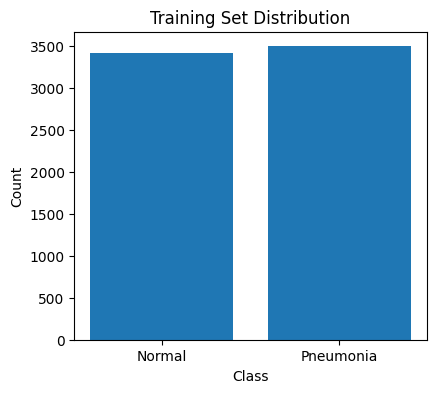

Imbalance Ratio (Pneumonia : Normal) = 1.02 : 1


In [ ]:
classes = ['Normal', 'Pneumonia']
train_counts = [train_normal, train_pneu]

plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.bar(classes, train_counts)
plt.title("Training Set Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# Check imbalance ratio
normal = train_normal
pneumonia = train_pneu
imbalance_ratio = pneumonia / normal

print(f"Imbalance Ratio (Pneumonia : Normal) = {imbalance_ratio:.2f} : 1")

Data Augmentation

In [ ]:
split_train_dir = os.path.join(base_dir, "train")
split_val_dir = os.path.join(base_dir, "val")
split_test_dir = os.path.join(base_dir, "test")

In [ ]:
IMG_SIZE = (224, 224)  # ResNet50 / DenseNet121 / MobileNet / VGG19 standard input

# --- Train Augmentation ---
def create_train_generator(preprocess_func):
    return ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True
    ).flow_from_directory(
        split_train_dir,
        target_size=IMG_SIZE,
        batch_size=32,
        class_mode="binary"
    )

# --- Validation / Test ---
def create_val_generator(preprocess_func, folder):
    return ImageDataGenerator(preprocessing_function=preprocess_func).flow_from_directory(
        folder,
        target_size=IMG_SIZE,
        batch_size=32,
        class_mode="binary",
        shuffle=False
    )


Build Transfer Learning Model

In [ ]:
def build_model(base_model_class, preprocess_func, input_shape=(*IMG_SIZE,3), dropout_rate=0.5):
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze base layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Make sure the log directory exists
os.makedirs('/content/drive/MyDrive/IIT/FYP/Implementation/logs', exist_ok=True)

# Make sure the model directory exists (optional, but good practice)
os.makedirs('/content/drive/MyDrive/IIT/FYP/Implementation/models', exist_ok=True)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

def get_callbacks(model_name, monitor_metric='val_accuracy', patience=8):
    """
    Returns a set of callbacks for model training with unique file names per model.
    Args:
        model_name (str): A short name for your model (e.g., 'resnet', 'mobilenet', 'DenseNet121').
        monitor_metric (str): Metric to monitor for early stopping and checkpointing.
        patience (int): Number of epochs to wait before early stopping.

    Returns:
        list: [EarlyStopping, ModelCheckpoint, CSVLogger]
    """
    early_stop = EarlyStopping(
        monitor=monitor_metric,
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/IIT/FYP/Implementation/models/{model_name}_best.keras",
        monitor=monitor_metric,
        save_best_only=True,
        verbose=1
    )

    csv_logger = CSVLogger(f"/content/drive/MyDrive/IIT/FYP/Implementation/logs/{model_name}_training_log.csv", append=True)

    return [early_stop, checkpoint, csv_logger]


Train ResNet50

In [ ]:
# Create the train and validation data generators
train_gen_resnet = create_train_generator(resnet_preprocess)
val_gen_resnet = create_val_generator(resnet_preprocess, split_val_dir)

Found 6914 images belonging to 2 classes.
Found 524 images belonging to 2 classes.


In [ ]:
# Build the ResNet50 model for transfer learning
resnet_model = build_model(ResNet50, resnet_preprocess)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train the model
callbacks_ResNet= get_callbacks("ResNet50")
history_resnet = resnet_model.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=30,
    callbacks=callbacks_ResNet
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7345 - loss: 0.6052 
Epoch 1: val_accuracy improved from -inf to 0.92366, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 3407s 16s/step - accuracy: 0.7349 - loss: 0.6044 - val_accuracy: 0.9237 - val_loss: 0.1734
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8953 - loss: 0.2722
Epoch 2: val_accuracy improved from 0.92366 to 0.93893, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 156s 716ms/step - accuracy: 0.8953 - loss: 0.2722 - val_accuracy: 0.9389 - val_loss: 0.1515
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9192 - loss: 0.2148
Epoch 3: val_accuracy improved from 0.93893 to 0.94656, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 160s 737ms/step - accuracy: 0.9192 

Train DenseNet121

In [ ]:
# DenseNet121
train_gen_dense = create_train_generator(densenet_preprocess)
val_gen_dense = create_val_generator(densenet_preprocess, split_val_dir)

Found 6914 images belonging to 2 classes.
Found 524 images belonging to 2 classes.


In [ ]:
dense_model = build_model(DenseNet121, densenet_preprocess)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
callbacks_DenseNet= get_callbacks("DenseNet121")
history_dense = dense_model.fit(
    train_gen_dense,
    validation_data=val_gen_dense,
    epochs=30,
    callbacks=callbacks_DenseNet
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6353 - loss: 0.7708
Epoch 1: val_accuracy improved from -inf to 0.91031, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/DenseNet121_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 1815s 8s/step - accuracy: 0.6357 - loss: 0.7701 - val_accuracy: 0.9103 - val_loss: 0.2579
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8150 - loss: 0.4210
Epoch 2: val_accuracy improved from 0.91031 to 0.93893, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/DenseNet121_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 151s 692ms/step - accuracy: 0.8151 - loss: 0.4210 - val_accuracy: 0.9389 - val_loss: 0.2082
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.8507 - loss: 0.3484
Epoch 3: val_accuracy improved from 0.93893 to 0.94847, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/DenseNet121_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 150s 692ms/step - accuracy: 0

Train MobileNet

In [ ]:
train_gen_mobile = create_train_generator(mobilenet_preprocess)
val_gen_mobile = create_val_generator(mobilenet_preprocess, split_val_dir)

Found 6914 images belonging to 2 classes.
Found 524 images belonging to 2 classes.


In [ ]:
mobile_model = build_model(MobileNet, mobilenet_preprocess)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
callbacks_mobile= get_callbacks("MobileNet")
history_mobile = mobile_model.fit(
    train_gen_mobile,
    validation_data=val_gen_mobile,
    epochs=30,
    callbacks=callbacks_mobile
    )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.6305 - loss: 0.8486 
Epoch 1: val_accuracy improved from -inf to 0.94084, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/MobileNet_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 4116s 19s/step - accuracy: 0.6309 - loss: 0.8476 - val_accuracy: 0.9408 - val_loss: 0.1893
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8517 - loss: 0.3391
Epoch 2: val_accuracy improved from 0.94084 to 0.94656, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/MobileNet_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 145s 666ms/step - accuracy: 0.8517 - loss: 0.3391 - val_accuracy: 0.9466 - val_loss: 0.1556
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.8834 - loss: 0.2803
Epoch 3: val_accuracy did not improve from 0.94656
217/217 ━━━━━━━━━━━━━━━━━━━━ 143s 660ms/step - accuracy: 0.8834 - loss: 0.2803 - val_accuracy: 0.9408 - val_loss: 0.1532
Epoch 4/30
217/217 ━━━━━━━━━━━━━━━━

Train VGG19

In [ ]:
# Create train & validation generators
train_gen_vgg = create_train_generator(vgg19_preprocess)
val_gen_vgg = create_val_generator(vgg19_preprocess, split_val_dir)

Found 6914 images belonging to 2 classes.
Found 524 images belonging to 2 classes.


In [ ]:
# Build model
vgg_model = build_model(VGG19, vgg19_preprocess)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Get callbacks
callbacks_vgg = get_callbacks("vgg19")

# Train the model
history_vgg = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=30,
    callbacks=callbacks_vgg
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5637 - loss: 2.4289
Epoch 1: val_accuracy improved from -inf to 0.87786, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/vgg19_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 1968s 9s/step - accuracy: 0.5640 - loss: 2.4261 - val_accuracy: 0.8779 - val_loss: 0.3120
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.7638 - loss: 0.9638
Epoch 2: val_accuracy improved from 0.87786 to 0.90076, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/vgg19_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 165s 761ms/step - accuracy: 0.7638 - loss: 0.9637 - val_accuracy: 0.9008 - val_loss: 0.2508
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.7940 - loss: 0.6949
Epoch 3: val_accuracy improved from 0.90076 to 0.91794, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/vgg19_best.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 164s 753ms/step - accuracy: 0.7940 - loss: 0.69